In [1]:
import torch

print("PyTorch Version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected.")

PyTorch Version: 2.11.0+cu128
GPU Available: True
GPU Name: Tesla T4


In [2]:
!pip install torch torchvision pillow matplotlib

In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image
import matplotlib.pyplot as plt

from torchvision import transforms, models

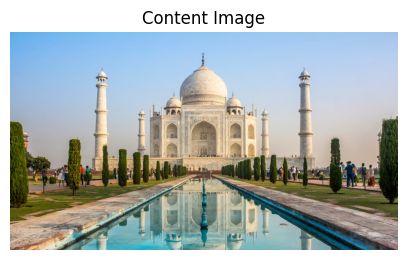

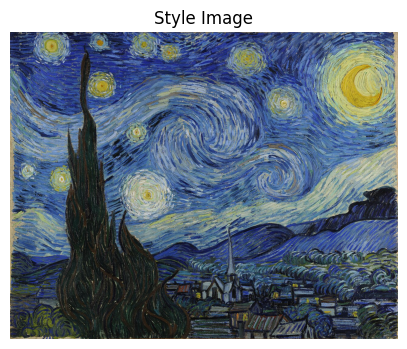

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

# Load images
content = Image.open("content_image.jpg")
style = Image.open("style_image.jpg")

# Show Content Image
plt.figure(figsize=(5,5))
plt.imshow(content)
plt.title("Content Image")
plt.axis("off")
plt.show()

# Show Style Image
plt.figure(figsize=(5,5))
plt.imshow(style)
plt.title("Style Image")
plt.axis("off")
plt.show()

In [6]:
import torch
from torchvision import transforms

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Image size
imsize = 512 if torch.cuda.is_available() else 128

# Transform
loader = transforms.Compose([
    transforms.Resize((imsize, imsize)),
    transforms.ToTensor()
])

def load_image(image_name):
    image = Image.open(image_name).convert("RGB")
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)

# Load images
content_img = load_image("content_image.jpg")
style_img = load_image("style_image.jpg")

print("Content Image Shape:", content_img.shape)
print("Style Image Shape:", style_img.shape)

Content Image Shape: torch.Size([1, 3, 512, 512])
Style Image Shape: torch.Size([1, 3, 512, 512])


In [7]:
from torchvision import models

# Load pre-trained VGG19 model
cnn = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()

print("VGG19 model loaded successfully!")

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 79.0MB/s]


VGG19 model loaded successfully!


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------- Gram Matrix ----------
def gram_matrix(input):
    a, b, c, d = input.size()

    features = input.view(a * b, c * d)
    G = torch.mm(features, features.t())

    return G.div(a * b * c * d)


# ---------- Content Loss ----------
class ContentLoss(nn.Module):

    def __init__(self, target):
        super(ContentLoss, self).__init__()
        self.target = target.detach()

    def forward(self, input):
        self.loss = F.mse_loss(input, self.target)
        return input


# ---------- Style Loss ----------
class StyleLoss(nn.Module):

    def __init__(self, target_feature):
        super(StyleLoss, self).__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input):
        G = gram_matrix(input)
        self.loss = F.mse_loss(G, self.target)
        return input

print("Content Loss and Style Loss loaded successfully!")

Content Loss and Style Loss loaded successfully!


In [10]:
# ---------- Normalization ----------
class Normalization(nn.Module):

    def __init__(self, mean, std):
        super(Normalization, self).__init__()

        self.mean = torch.tensor(mean).view(-1, 1, 1).to(device)
        self.std = torch.tensor(std).view(-1, 1, 1).to(device)

    def forward(self, img):
        return (img - self.mean) / self.std


# ImageNet mean and std
cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(device)

print("Normalization Layer Loaded Successfully!")

Normalization Layer Loaded Successfully!


In [11]:
import copy

# Layers used for style and content
content_layers = ['conv_4']
style_layers = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']

def get_style_model_and_losses(
    cnn,
    normalization_mean,
    normalization_std,
    style_img,
    content_img):

    cnn = copy.deepcopy(cnn)

    normalization = Normalization(
        normalization_mean,
        normalization_std
    ).to(device)

    content_losses = []
    style_losses = []

    model = nn.Sequential(normalization)

    i = 0

    for layer in cnn.children():

        if isinstance(layer, nn.Conv2d):
            i += 1
            name = f'conv_{i}'

        elif isinstance(layer, nn.ReLU):
            name = f'relu_{i}'
            layer = nn.ReLU(inplace=False)

        elif isinstance(layer, nn.MaxPool2d):
            name = f'pool_{i}'

        elif isinstance(layer, nn.BatchNorm2d):
            name = f'bn_{i}'

        else:
            raise RuntimeError(
                f'Unrecognized layer: {layer.__class__.__name__}'
            )

        model.add_module(name, layer)

        if name in content_layers:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module(f"content_loss_{i}", content_loss)
            content_losses.append(content_loss)

        if name in style_layers:
            target_feature = model(style_img).detach()
            style_loss = StyleLoss(target_feature)
            model.add_module(f"style_loss_{i}", style_loss)
            style_losses.append(style_loss)

    # Remove layers after last loss
    for j in range(len(model) - 1, -1, -1):
        if isinstance(model[j], ContentLoss) or isinstance(model[j], StyleLoss):
            break

    model = model[:j + 1]

    return model, style_losses, content_losses


print("Style Transfer Model Created Successfully!")

Style Transfer Model Created Successfully!


In [12]:
# Create a copy of the content image
input_img = content_img.clone()

# Build the model
model, style_losses, content_losses = get_style_model_and_losses(
    cnn,
    cnn_normalization_mean,
    cnn_normalization_std,
    style_img,
    content_img
)

# Optimizer
optimizer = torch.optim.LBFGS([input_img.requires_grad_()])

print("Model and Optimizer Ready!")

/tmp/ipykernel_1836/2320869319.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(mean).view(-1, 1, 1).to(device)
/tmp/ipykernel_1836/2320869319.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std = torch.tensor(std).view(-1, 1, 1).to(device)


Model and Optimizer Ready!


In [13]:
num_steps = 300
style_weight = 1000000
content_weight = 1

print("Optimizing...")

run = [0]

while run[0] <= num_steps:

    def closure():

        input_img.data.clamp_(0, 1)

        optimizer.zero_grad()

        model(input_img)

        style_score = 0
        content_score = 0

        for sl in style_losses:
            style_score += sl.loss

        for cl in content_losses:
            content_score += cl.loss

        style_score *= style_weight
        content_score *= content_weight

        loss = style_score + content_score
        loss.backward()

        run[0] += 1

        if run[0] % 50 == 0:
            print(f"Step {run[0]}/{num_steps}")

        return loss

    optimizer.step(closure)

input_img.data.clamp_(0, 1)

print("Style Transfer Completed!")

Optimizing...
Step 50/300
Step 100/300
Step 150/300
Step 200/300
Step 250/300
Step 300/300
Style Transfer Completed!


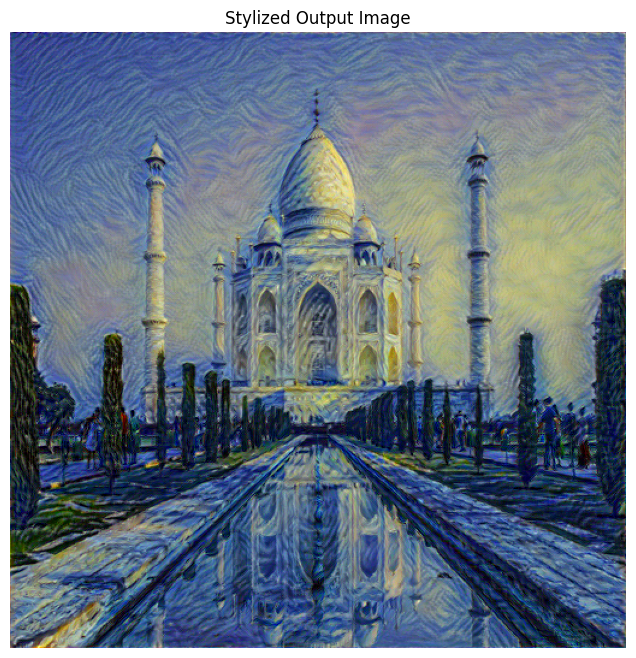

Image saved successfully!
Saved at: output_images/output.png


In [14]:
from torchvision.transforms.functional import to_pil_image
import matplotlib.pyplot as plt
import os

# Create output folder
os.makedirs("output_images", exist_ok=True)

# Convert tensor to image
output = input_img.cpu().clone()
output = output.squeeze(0)

# Convert to PIL Image
output_image = to_pil_image(output)

# Save image
output_path = "output_images/output.png"
output_image.save(output_path)

# Display image
plt.figure(figsize=(8,8))
plt.imshow(output_image)
plt.title("Stylized Output Image")
plt.axis("off")
plt.show()

print("Image saved successfully!")
print("Saved at:", output_path)

### Create `app.py` for serving the stylized image

In [15]:
%%writefile app.py
from flask import Flask, send_from_directory, render_template_string
import os

app = Flask(__name__)

# HTML template for the main page
HTML_TEMPLATE = '''
<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8">
  <title>Stylized Image</title>
  <style>
    body { font-family: sans-serif; text-align: center; margin-top: 50px; }
    img { max-width: 90%; height: auto; border: 2px solid #ccc; }
  </style>
</head>
<body>
  <h1>Your Stylized Image</h1>
  <img src="/output/output.png" alt="Stylized Image">
  <p>Image generated using Neural Style Transfer.</p>
</body>
</html>
'''

@app.route('/')
def index():
    return render_template_string(HTML_TEMPLATE)

@app.route('/output/<path:filename>')
def serve_output_image(filename):
    # Ensure the path is correct for where output_images is created
    return send_from_directory(os.path.join(os.getcwd(), 'output_images'), filename)

if __name__ == '__main__':
    # In a Colab environment, use a public URL if available, otherwise a simple run
    # For deployment, consider using a proper WSGI server like Gunicorn
    app.run(host='0.0.0.0', port=5000, debug=True)


Writing app.py


You can run this Flask application using the command `python app.py` in your terminal. If you are running this in Google Colab, you might need to use `ngrok` or similar tools to expose the port to the internet.

Alternatively, you can just click the link below to view the generated image directly:

```python
from IPython.display import Image, display
display(Image('output_images/output.png'))
```

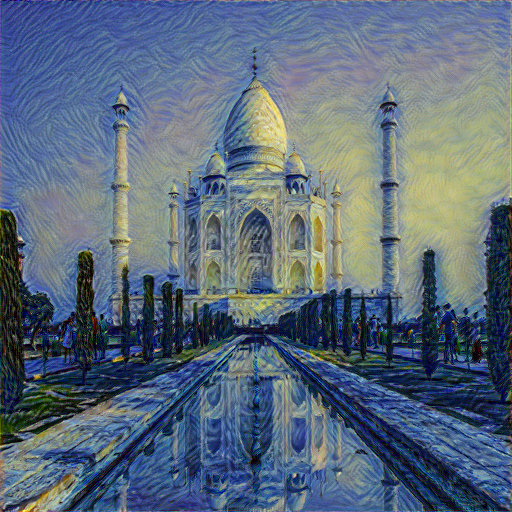

In [16]:
from IPython.display import Image, display
display(Image('output_images/output.png'))

### Generate `requirements.txt` file

In [17]:
%%writefile requirements.txt
torch
torchvision
pillow
matplotlib
flask


Writing requirements.txt
